In [ ]:
# Trajectory archetypes from data/clean_runs.json: individual trajectories
# (per-agent flip classes) and group trajectories (per-society band classes).
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

from utils import (MODELS, REGIMES, TAU, IND_CLASSES, GRP_CLASSES, load_data,
                   opinions, flip_counts, individual_archetypes, group_archetypes)

runs, banks, P, GCLASS = load_data()

# Compute each run's mean opinion \bar{o}_i
for r in runs:
    # opinions: Computes the mean opinion of each agent over the last 5 rounds of the simulation.
    r["opinions"] = opinions(r)  # (9 rounds, 32 agents), k=5-resample means
print(len(runs), "societies")

9600 societies


In [ ]:
"""
Figure 2: Individual Archetypes
"""
# individual trajectories: flip count F -> frozen 0 / switcher 1 /
# intermittent 2 / oscillating >=3, per (model, regime)
IND_TITLES = ["Frozen (F = 0)", "Switcher (F = 1)",
              "Intermittent (F = 2)", "Oscillating (F ≥ 3)"]

# 1. Stack the opinions of all runs for each (model, regime) pair
by_pair = {(m, rg): np.stack([r["opinions"] for r in runs
                              if r["model"] == m and r["mode"] == rg])
           for m, _, _ in MODELS for rg in ["objective", "subjective"]}
# 2. Compute the individual archetype classes for each (model, regime) pair
ind_cls = {k: individual_archetypes(v) for k, v in by_pair.items()}
# 3. For each model and question regime, compute the percentage of agents in each individual archetype class
ind_shares = np.array([[100 * np.bincount(ind_cls[m, rg].ravel(), minlength=4)
                        / ind_cls[m, rg].size
                        for rg in ["objective", "subjective"]]
                       for m, _, _ in MODELS]).transpose(0, 2, 1)
pd.DataFrame(ind_shares[:, :, 0], index=[l for _, l, _ in MODELS],
             columns=IND_TITLES).round(1)

,Frozen (F = 0),Switcher (F = 1),Intermittent (F = 2),Oscillating (F ≥ 3)
GPT-4o-mini,29.0,19.1,8.9,43.0
Gemma-3n-E4B,64.6,10.6,10.0,14.8
Qwen3.5-9B,40.6,25.4,8.1,25.9
Llama-3-8B,47.5,16.7,10.6,25.2


In [ ]:
# white -> purple composition table: models x (class x Objective|Subjective)
PURPLE = mcolors.LinearSegmentedColormap.from_list("purple", ["#f7f7fa", "#8e44ad"])

# Helper function to plot the composition table of individual archetypes
def composition_table(ax, shares, row_labels):
    n_m, n_c, _ = shares.shape
    grid = shares.reshape(n_m, n_c * 2)
    ax.imshow(grid, cmap=PURPLE, vmin=0, vmax=100, aspect="auto")
    for i in range(n_m):
        for j in range(n_c * 2):
            v = grid[i, j]
            txt = "0" if v == 0 else f"{v:.1f}" if v < 10 else f"{v:.0f}"
            ax.text(j, i, txt + "%", ha="center", va="center", fontsize=8,
                    color="white" if v > 50 else "#2a2a2a")
    for j in range(n_c * 2 + 1):
        ax.axvline(j - 0.5, color="white", lw=1.5 if j % 2 else 3.5)
    for i in range(n_m + 1):
        ax.axhline(i - 0.5, color="white", lw=1.5)
    ax.set_yticks(range(n_m), row_labels, fontsize=10)
    ax.set_xticks(range(n_c * 2), ["O", "S"] * n_c, fontsize=9)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

In [ ]:
# one archetypal example agent per class: soft frozen/oscillating, a
# mid-run switcher, an intermittent with balanced dwells

# Computes the lengths of contiguous segments of positive or negative values in a trajectory, ignoring zeros.
def dwell_segments(m):
    signs, prev = [], 0
    for v in m:
        prev = 1 if v > 0 else -1 if v < 0 else prev
        signs.append(prev)
    return [len(list(g)) for s, g in itertools.groupby(signs) if s]

# Computes scores for each trajectory based on its flip count F, dwell segments, mean opinion sat, and number of steps n_steps.
def example_scores(F, segs, sat, n_steps):
    """
    0 -> frozen: score is higher when mean opinion is closer to 0.5
    1 -> switcher: score is higher when mean opinion is higher and the first dwell segment is closer to half of the total steps
    2 -> intermittent: score is higher when the shortest dwell segment is longer and the mean opinion is higher
    3 -> oscillating: score is higher when the flip count is higher and the mean opinion is closer to 0.5
    """
    return {0: -abs(sat - 0.5) if F == 0 else None, 
            1: sat - abs(segs[0] - n_steps / 2) if F == 1 else None, 
            2: min(segs) * 10 + sat if F == 2 else None, 
            3: -10 * (F - 3) - abs(sat - 0.5) if F >= 3 else None} # !! Check needed: Shouldn't this be 10 * (F - 3) - abs(sat - 0.5)?

# Find the best example trajectory for each individual archetype class based on the scoring function.
ind_examples = [None] * 4
for r in runs:
    for traj in r["opinions"].T:
        F = int(flip_counts(traj[None, :, None])[0, 0])
        scores = example_scores(F, dwell_segments(traj),
                                float(np.abs(traj).mean()), len(traj))
        for c, score in scores.items():
            if score is not None and (ind_examples[c] is None
                                      or score > ind_examples[c][0]):
                ind_examples[c] = (score, traj.copy())

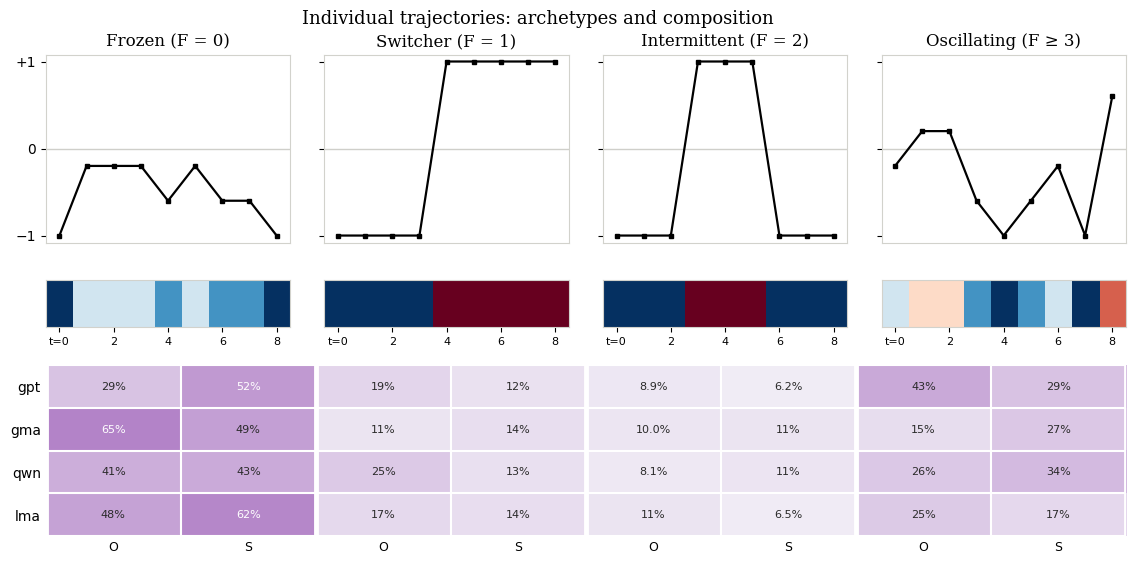

In [5]:
fig = plt.figure(figsize=(12, 5.6))
gs = fig.add_gridspec(3, 4, height_ratios=[2.2, 0.55, 2.0], hspace=0.28,
                      wspace=0.14, left=0.09, right=0.99, top=0.92, bottom=0.06)
T = 9
for c, title in enumerate(IND_TITLES):
    traj = ind_examples[c][1]
    ax = fig.add_subplot(gs[0, c])
    ax.axhline(0, color="#cfcfca", lw=1)
    ax.plot(range(T), traj, color="black", lw=1.6, marker="s", ms=3.5)
    ax.set_title(title, fontsize=12, family="serif")
    ax.set_xlim(-0.5, T - 0.5), ax.set_ylim(-1.08, 1.08)
    ax.set_xticks([])
    ax.set_yticks([-1, 0, 1], ["−1", "0", "+1"] if c == 0 else [])
    for s in ax.spines.values():
        s.set_color("#d2d2cc")
    ax = fig.add_subplot(gs[1, c])
    ax.imshow(traj[None, :], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(0, T, 2), ["t=0", "2", "4", "6", "8"], fontsize=8)
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color("#d2d2cc")
ax = fig.add_subplot(gs[2, :])
composition_table(ax, ind_shares, [sh for _, _, sh in MODELS])
fig.suptitle("Individual trajectories: archetypes and composition",
             fontsize=13, family="serif", y=1.0)
plt.show()

In [ ]:
"""
Figure 3: Group Archetypes
"""
# group trajectories: net opinion n(t) vs the split band (|n| >= 0.2 is a
# majority), class from the initial vs final round

# 1. Compute the net opinion for each run by averaging the opinions across agents at each time step.
for r in runs:
    r["net"] = r["opinions"].mean(axis=1)
# 2. Group the trajectories by their initial and final net opinions.
grp_cls = {}
for m, _, _ in MODELS:
    for rg in ["objective", "subjective"]:
        net = np.stack([r["net"] for r in runs
                        if r["model"] == m and r["mode"] == rg])
        grp_cls[m, rg] = group_archetypes(net[:, 0], net[:, -1])
# 3. For each model and question regime, compute the percentage of runs in each group archetype class
grp_shares = np.array([[100 * np.bincount(grp_cls[m, rg], minlength=5)
                        / len(grp_cls[m, rg])
                        for rg in ["objective", "subjective"]]
                       for m, _, _ in MODELS]).transpose(0, 2, 1)
pd.DataFrame(grp_shares[:, :, 0], index=[l for _, l, _ in MODELS],
             columns=GRP_CLASSES).round(1)

,Persistent Split,Convergence,Divergence,Majority Switch,Persistent Majority
GPT-4o-mini,21.9,68.0,1.2,2.1,6.8
Gemma-3n-E4B,0.0,8.5,3.2,8.0,80.2
Qwen3.5-9B,6.9,55.6,1.1,6.3,30.1
Llama-3-8B,4.6,33.9,2.3,4.8,54.4


In [ ]:
# one archetypal example society per class: clear-cut extremes, gradual
# transitions preferred for convergence / majority switch

def group_example_score(c, n):
    """
    c: class index (0 to 4) representing the group archetype
    n: net opinion trajectory (list or array of net opinions over time)
    
    Returns a score for the trajectory based on its characteristics.
    Note that this scoring is used after the group archetype has been determined, not to determine the archetype itself.

    0 -> persistent split: Score is higher when the initial and final net opinions are both close to zero
    1 -> convergence: Score is higher when the final net opinion is further from zero than the initial net opinion, and the maximum step change is smaller
    2 -> divergence: Score is higher when the initial net opinion is further from zero than the final net opinion
    3 -> majority switch: Score is higher when the initial and final net opinions are both far from zero, and the maximum step change is smaller
    4 -> persistent majority: Score is higher when the initial and final net opinions are both far from zero
    """
    # step is the maximum absolute change in net opinion between consecutive time steps.
    step = max(abs(b - a) for a, b in zip(n, n[1:])) 
    return [-abs(n[0]) - abs(n[-1]), abs(n[-1]) - abs(n[0]) - step,
            abs(n[0]) - abs(n[-1]), min(abs(n[0]), abs(n[-1])) - step,
            min(abs(n[0]), abs(n[-1]))][c]

grp_examples = [None] * 5
for r in runs:
    c = int(group_archetypes(r["net"][0], r["net"][-1]))
    score = group_example_score(c, r["net"])
    if grp_examples[c] is None or score > grp_examples[c][0]:
        grp_examples[c] = (score, r)

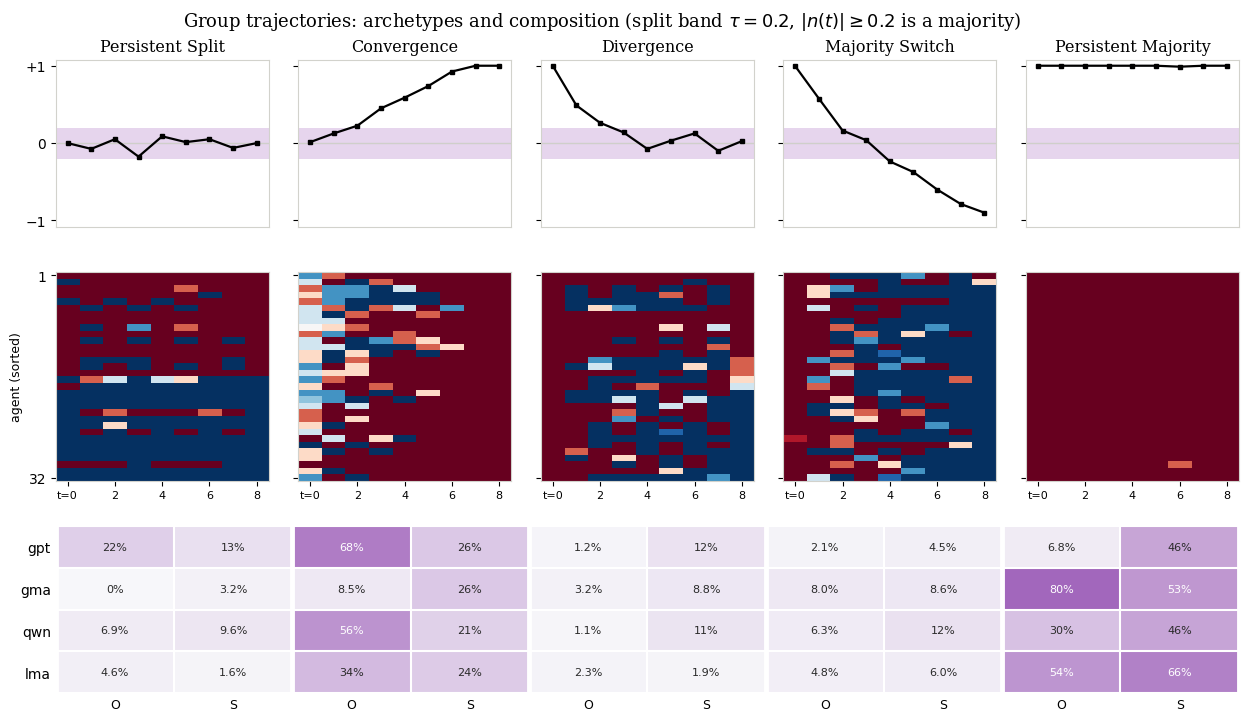

In [8]:
fig = plt.figure(figsize=(13, 7.2))
gs = fig.add_gridspec(3, 5, height_ratios=[1.6, 2.0, 1.6], hspace=0.25,
                      wspace=0.14, left=0.08, right=0.99, top=0.93, bottom=0.05)
for c, title in enumerate(GRP_CLASSES):
    r = grp_examples[c][1]
    ax = fig.add_subplot(gs[0, c])
    ax.axhspan(-TAU, TAU, color="#8e44ad", alpha=0.22, lw=0)
    ax.axhline(0, color="#cfcfca", lw=1)
    ax.plot(range(T), r["net"], color="black", lw=1.6, marker="s", ms=3.2)
    ax.set_title(title, fontsize=11.5, family="serif")
    ax.set_xlim(-0.5, T - 0.5), ax.set_ylim(-1.08, 1.08)
    ax.set_xticks([])
    ax.set_yticks([-1, 0, 1], ["−1", "0", "+1"] if c == 0 else [])
    for s in ax.spines.values():
        s.set_color("#d2d2cc")
    ax = fig.add_subplot(gs[1, c])
    order = np.argsort(-r["opinions"][-1])  # agents sorted by final round
    ax.imshow(r["opinions"].T[order], cmap="RdBu_r", vmin=-1, vmax=1,
              aspect="auto", interpolation="nearest")
    ax.set_xticks(range(0, T, 2), ["t=0", "2", "4", "6", "8"], fontsize=8)
    ax.set_yticks([0, 31], ["1", "32"] if c == 0 else [])
    if c == 0:
        ax.set_ylabel("agent (sorted)", fontsize=9)
    for s in ax.spines.values():
        s.set_color("#d2d2cc")
ax = fig.add_subplot(gs[2, :])
composition_table(ax, grp_shares, [sh for _, _, sh in MODELS])
fig.suptitle(r"Group trajectories: archetypes and composition "
             r"(split band $\tau = 0.2$, $|n(t)| \geq 0.2$ is a majority)",
             fontsize=13, family="serif", y=1.0)
plt.show()